# 1. Strategy A data: G10 FX, interest rates and CFTC positioning

Strategy A needs three ingredients, all monthly:

| Data | What it is for | Source |
|---|---|---|
| FX spot rates | currency returns | FRED (Fed H.10) |
| 3-month interest rates | the carry signal (rate differential vs USD) | OECD via FRED |
| CFTC Commitments of Traders | **alternative data**: how crowded speculators are | cftc.gov |

By default this notebook **loads the cleaned files already in `data/clean/`**. Set `DOWNLOAD = True` to rebuild them from the internet (FRED often blocks scripts, so first save the FRED CSVs by hand as `data/raw/fred_<SERIES_ID>.csv`, see the README).

In [1]:
# Setup: run everything from the project root so the scripts' relative paths work
import os, importlib.util
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
print("Working directory:", Path.cwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
%matplotlib inline

def load_script(path, name):
    """Import a numbered script from code/ (file names starting with a digit can't be imported normally)."""
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

Working directory: /Users/reza/Desktop/mfe-term_3/currency_market/currency-crypto-carry


In [2]:
DOWNLOAD = False   # True = re-download and rebuild data/clean (slow, needs internet)

## Step 1 - (optional) download and clean
This runs exactly the same functions as `code/01_download_data_strategyA.py`.

In [3]:
A = load_script("code/01_download_data_strategyA.py", "dataA")
if DOWNLOAD:
    spot = A.build_fx()
    rates = A.build_rates()
    net = A.build_positioning()
else:
    print("Using the committed data in data/clean/ (set DOWNLOAD = True to rebuild)")

Using the committed data in data/clean/ (set DOWNLOAD = True to rebuild)


## Step 2 - load the cleaned data

In [4]:
spot = pd.read_csv("data/clean/fx_spot_monthly_usd_per_fcu.csv", index_col=0, parse_dates=True)
rates = pd.read_csv("data/clean/rates_3m_monthly.csv", index_col=0, parse_dates=True)
cftc = pd.read_csv("data/clean/cftc_net_spec_monthly.csv", index_col=0, parse_dates=True)
for name, df in [("FX spot (USD per foreign currency)", spot), ("3-month rates (% p.a.)", rates),
                 ("CFTC net speculative position / open interest", cftc)]:
    print(f"\n{name}")
    A.summarize(name, df)


FX spot (USD per foreign currency)

=== FX spot (USD per foreign currency) ===
  JPY: 1971-01 to 2026-09, 669 obs, last = 0.0064
  EUR: 1999-01 to 2026-09, 333 obs, last = 1.1400
  GBP: 1971-01 to 2026-09, 669 obs, last = 1.3250
  CHF: 1971-01 to 2026-09, 669 obs, last = 1.2074
  CAD: 1971-01 to 2026-09, 669 obs, last = 0.7072
  AUD: 1971-01 to 2026-09, 669 obs, last = 0.7033
  NZD: 1971-01 to 2026-09, 669 obs, last = 0.5667

3-month rates (% p.a.)

=== 3-month rates (% p.a.) ===
  USD: 1964-06 to 2026-08, 746 obs, last = 3.8200
  JPY: 2002-04 to 2026-07, 292 obs, last = 1.4585
  EUR: 1960-01 to 2026-08, 800 obs, last = 2.5131
  GBP: 1957-01 to 2026-01, 829 obs, last = 3.7100
  CHF: 1999-07 to 2026-08, 326 obs, last = -0.0450
  CAD: 1956-01 to 2026-08, 848 obs, last = 2.2800
  AUD: 1968-01 to 2026-08, 704 obs, last = 4.5100
  NZD: 1973-12 to 2026-08, 633 obs, last = 2.9800

CFTC net speculative position / open interest

=== CFTC net speculative position / open interest ===
  AUD: 1987

## Step 3 - look at the data
**Interest differentials** (foreign 3-month rate minus the US rate) are the carry signal. Large positive values = a high-yield currency (AUD, NZD); negative = a funding currency (JPY, CHF).

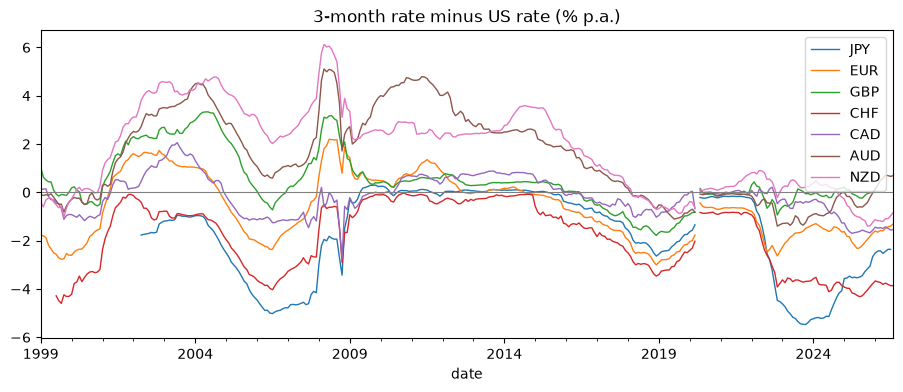

In [5]:
diff = rates.drop(columns="USD").sub(rates["USD"], axis=0)
ax = diff.loc["1999":].plot(figsize=(11, 4), lw=1, title="3-month rate minus US rate (% p.a.)")
ax.axhline(0, color="grey", lw=0.8); plt.show()

**CFTC positioning**: net long of non-commercial traders (speculators) as a share of open interest. +0.3 means speculators are heavily long that currency against USD.

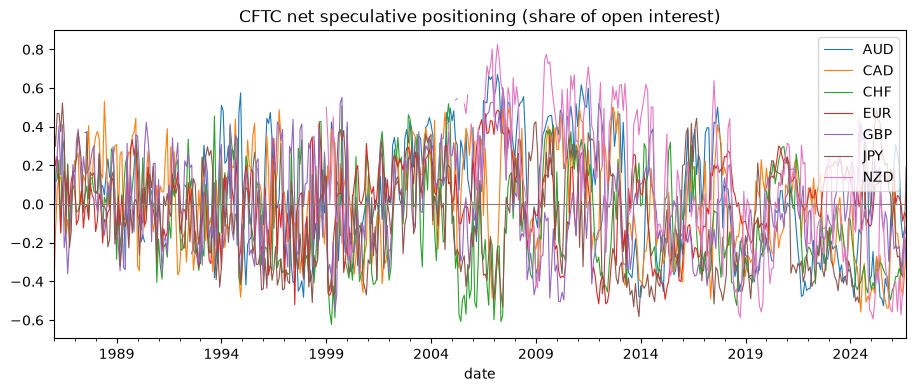

In [6]:
ax = cftc.plot(figsize=(11, 4), lw=0.8, title="CFTC net speculative positioning (share of open interest)")
ax.axhline(0, color="grey", lw=0.8); plt.show()

## Step 4 - which CFTC contracts did we match?
Before August 2000 the CME currency futures are reported under the exchange name *INTERNATIONAL MONETARY MARKET*; the matching function accepts both names and drops crosses and mini contracts.

In [7]:
examples = ["JAPANESE YEN - INTERNATIONAL MONETARY MARKET", "JAPANESE YEN - CHICAGO MERCANTILE EXCHANGE",
            "POUND STERLING - INTERNATIONAL MONETARY MARKET", "EURO FX/JAPANESE YEN XRATE - NEW YORK BOARD OF TRADE",
            "DEUTSCHE MARK, FORWARD - INTERNATIONAL MONETARY MARKET", "E-MINI EURO FX - CHICAGO MERCANTILE EXCHANGE"]
pd.Series({m: A.match_currency(m) for m in examples}, name="matched currency")

JAPANESE YEN - INTERNATIONAL MONETARY MARKET              JPY
JAPANESE YEN - CHICAGO MERCANTILE EXCHANGE                JPY
POUND STERLING - INTERNATIONAL MONETARY MARKET            GBP
EURO FX/JAPANESE YEN XRATE - NEW YORK BOARD OF TRADE      NaN
DEUTSCHE MARK, FORWARD - INTERNATIONAL MONETARY MARKET    NaN
E-MINI EURO FX - CHICAGO MERCANTILE EXCHANGE              NaN
Name: matched currency, dtype: str